# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [29]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [30]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,  
    'open_confidence': 0.4,  # 将被自适应计算覆盖
    'close_confidence': 0.6,  # 将被自适应计算覆盖
    'standard_num': 1000,
    'trailing_stop_pct': 0.001,
    'max_pct': 0.004,
    'min_pct': 0.001,

    'k_pct': 1,
    'k_up': 3,
    'k_down': 3,
    
    # 添加模型参数以支持自适应功能
    'model_type': 'xgboost',
    'model_params': {
        'n_estimators': 1000,
        'max_depth': 3,
        'learning_rate': 0.01,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'objective': 'binary:logistic',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 1,
    }
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

print("初始参数设置:")
print(f"  open_confidence: {param_dict['open_confidence']}")
print(f"  close_confidence: {param_dict['close_confidence']}")

初始参数设置:
  open_confidence: 0.4
  close_confidence: 0.6


## 获取交易日数据

In [31]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

train_dates, valid_dates, test_dates = split_dates(trade_dates,35,9,10)

总交易日数量: 54
交易日范围: 20260105 ~ 20260327
训练集: 20260105 ~ 20260302 (35天)
验证集: 20260303 ~ 20260313 (9天)
测试集: 20260316 ~ 20260327 (10天)


## 生成训练数据

In [32]:
print("生成训练集样本...")
X_train, y_train = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
if len(y_train) > 0:
    print(f"标签分布:\n{y_train.value_counts()}")

生成训练集样本...
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本
20260127: 产生 791 个样本
20260128: 产生 802 个样本
20260129: 产生 812 个样本
20260130: 产生 884 个样本
20260202: 产生 757 个样本
20260203: 产生 833 个样本
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
20260302: 产生 821 个样本
训练集样本: X=(27632, 13), y=(27632,)
标签分布:
0    19665
1     7967
Name: count, dtype: int64


In [33]:
print("生成验证集样本...")
X_valid, y_valid = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
if len(y_valid) > 0:
    print(f"标签分布:\n{y_valid.value_counts()}")

生成验证集样本...
20260303: 产生 794 个样本
20260304: 产生 886 个样本
20260305: 产生 807 个样本
20260306: 产生 780 个样本
20260309: 产生 804 个样本
20260310: 产生 783 个样本
20260311: 产生 763 个样本
20260312: 产生 759 个样本
20260313: 产生 750 个样本
验证集样本: X=(7126, 13), y=(7126,)
标签分布:
0    4995
1    2131
Name: count, dtype: int64


In [34]:
print("生成测试集样本...")
X_test, y_test = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")
if len(y_test) > 0:
    print(f"标签分布:\n{y_test.value_counts()}")

生成测试集样本...
20260316: 产生 755 个样本
20260317: 产生 762 个样本
20260318: 产生 795 个样本
20260319: 产生 792 个样本
20260320: 产生 815 个样本
20260323: 产生 844 个样本
20260324: 产生 842 个样本
20260325: 产生 783 个样本
20260326: 产生 862 个样本
20260327: 产生 787 个样本
测试集样本: X=(8037, 13), y=(8037,)
标签分布:
0    5659
1    2378
Name: count, dtype: int64


## 训练模型

In [ ]:
print("训练模型并计算自适应参数...")
model = train_model(X_train, y_train, X_valid, y_valid, param_dict)

# 计算自适应阈值
print("\n计算自适应阈值...")
open_confidence, close_confidence = calculate_adaptive_thresholds(model, X_valid, y_valid)
print(f"计算的自适应阈值: open_confidence={open_confidence:.4f}, close_confidence={close_confidence:.4f}")

# 更新参数字典中的阈值
param_dict['open_confidence'] = open_confidence
param_dict['close_confidence'] = close_confidence
print(f"已更新参数字典中的阈值参数")

# 显示自适应参数信息
print("\n自适应参数总结:")
print(f"  - open_confidence: {open_confidence:.4f} (验证集可信样本概率的中位数)")
print(f"  - close_confidence: {close_confidence:.4f} (验证集可信样本概率的80分位数)")
print(f"  - XGBoost scale_pos_weight: {model.scale_pos_weight if hasattr(model, 'scale_pos_weight') else 'N/A'}")
print("\n这些自适应参数将自动用于策略回测。")

训练模型并计算自适应参数...
训练 xgboost 模型...
优化类别权重...
  权重=1.2342 (因子=0.50): 召回率=0.1750, 精确率=0.4740, 得分=0.2074
  权重=1.8512 (因子=0.75): 召回率=0.3688, 精确率=0.4362, 得分=0.4022
  权重=2.4683 (因子=1.00): 召回率=0.5368, 精确率=0.4229, 得分=0.4229
  权重=3.0854 (因子=1.25): 召回率=0.6532, 精确率=0.4030, 得分=0.4030
  权重=3.7025 (因子=1.50): 召回率=0.7414, 精确率=0.3862, 得分=0.3862
  权重=4.3195 (因子=1.75): 召回率=0.8071, 精确率=0.3722, 得分=0.3722
  权重=4.9366 (因子=2.00): 召回率=0.8573, 精确率=0.3613, 得分=0.3613
  权重=5.5537 (因子=2.25): 召回率=0.8855, 精确率=0.3510, 得分=0.3510
  权重=6.1708 (因子=2.50): 召回率=0.9127, 精确率=0.3406, 得分=0.3406
  权重=6.7878 (因子=2.75): 召回率=0.9338, 精确率=0.3339, 得分=0.3339
  权重=7.4049 (因子=3.00): 召回率=0.9432, 精确率=0.3273, 得分=0.3273
  权重=12.3415 (因子=5.00): 召回率=0.9836, 精确率=0.3087, 得分=0.3087
最佳类别权重: 2.4683 (召回率=0.5368, 得分=0.4229)
[0]	validation_0-logloss:0.69318
[1]	validation_0-logloss:0.69295
[2]	validation_0-logloss:0.69271
[3]	validation_0-logloss:0.69249
[4]	validation_0-logloss:0.69197
[5]	validation_0-logloss:0.69144
[6]	validation_0-logloss:0.69099
[7

## 测试模型

测试集准确率: 0.6688

分类报告:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77      5659
           1       0.44      0.42      0.43      2378

    accuracy                           0.67      8037
   macro avg       0.60      0.60      0.60      8037
weighted avg       0.67      0.67      0.67      8037


PR曲线AUC: 0.4250
平均精度 (AP): 0.4255

预测概率统计:
  均值: 0.3577
  标准差: 0.2014
  最小值: 0.0202
  25%分位数: 0.1737
  中位数: 0.3460
  75%分位数: 0.5277
  最大值: 0.8088

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.3273, 标准差=0.1946
  标签1 (正类): 均值=0.4301, 标准差=0.1987


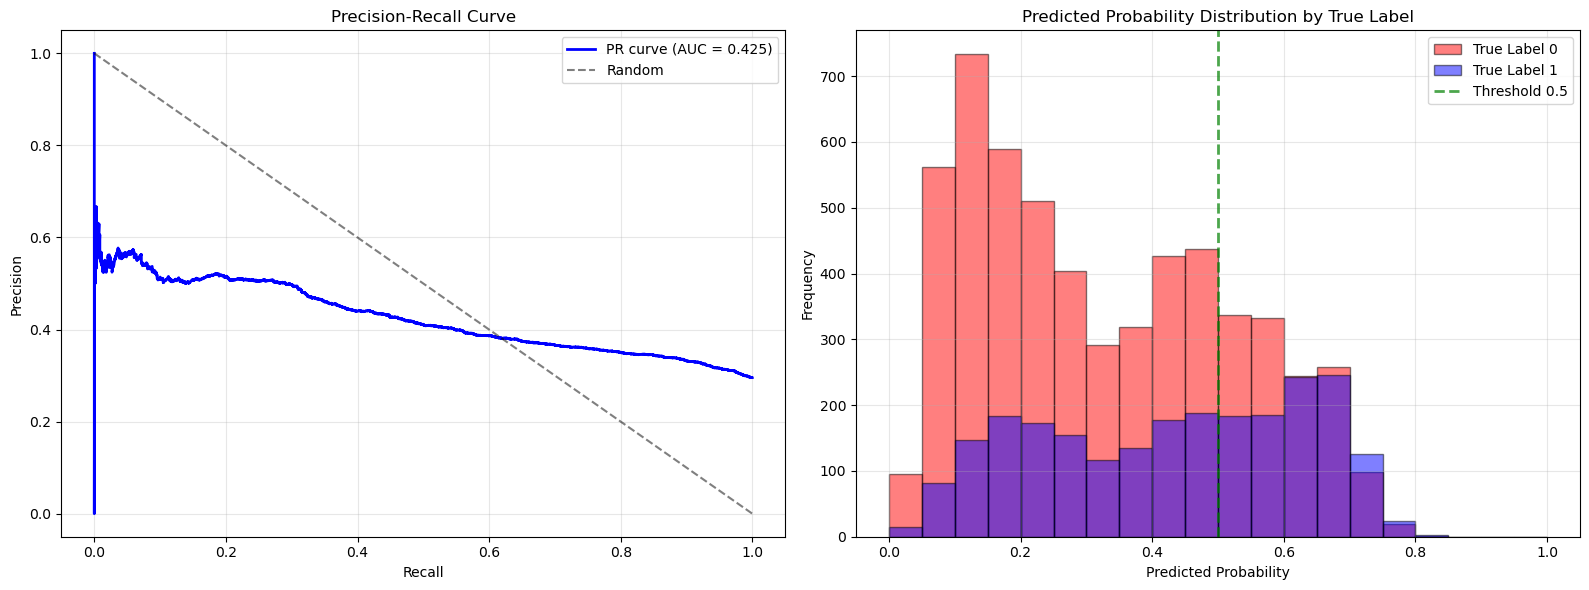

In [59]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

测试集准确率: 0.6700

分类报告:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77      5659
           1       0.44      0.43      0.44      2378

    accuracy                           0.67      8037
   macro avg       0.60      0.60      0.60      8037
weighted avg       0.67      0.67      0.67      8037

## 自适应参数说明

在训练模型后，我们计算了自适应参数：

1. **open_confidence**: 验证集可信样本概率输出的中位数
   - 用于开仓决策的置信度阈值
   - 计算值: 基于验证集动态计算

2. **close_confidence**: 验证集可信样本概率输出的75分位数
   - 用于平仓决策的置信度阈值
   - 计算值: 基于验证集动态计算

3. **XGBoost scale_pos_weight**: 自适应样本权重
   - 根据验证集表现优化的正负样本权重比例
   - 计算值: 基于验证集动态优化

这些参数已自动更新到参数字典中，策略实例将使用这些自适应参数进行决策。

## 创建策略实例

In [60]:
# 显示最终使用的参数
print("最终策略参数:")
print(f"  - open_confidence: {param_dict.get('open_confidence', 'N/A'):.4f}")
print(f"  - close_confidence: {param_dict.get('close_confidence', 'N/A'):.4f}")
print(f"  - open_threshold: {param_dict.get('open_threshold', 'N/A')}")
print(f"  - 策略名称: {param_dict.get('name', 'N/A')}")

# 获取XGBoost的scale_pos_weight
scale_pos_weight = 'N/A'
if hasattr(model, 'scale_pos_weight'):
    scale_pos_weight = model.scale_pos_weight
elif hasattr(model, 'get_params') and 'scale_pos_weight' in model.get_params():
    scale_pos_weight = model.get_params()['scale_pos_weight']
    
print(f"  - XGBoost scale_pos_weight: {scale_pos_weight}")

最终策略参数:
  - open_confidence: 0.4499
  - close_confidence: 0.6000
  - open_threshold: 2
  - 策略名称: delta_v1_adaptive
  - XGBoost scale_pos_weight: N/A


In [61]:
strategy = StrategyDemo(model, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

日期 20260303 完成，盈亏: 14.40, 成交: 19次
日期 20260304 完成，盈亏: -4.70, 成交: 26次
日期 20260305 完成，盈亏: -6.00, 成交: 21次
日期 20260306 完成，盈亏: 4.80, 成交: 8次

instrument_id 511090
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
20260305
20260306
20260309
20260310
20260311
20260312
20260313
20260316
20260317
20260318
20260319
20260320
20260323
20260324
20260325
20260326
20260327

instrument_id 511100
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
202

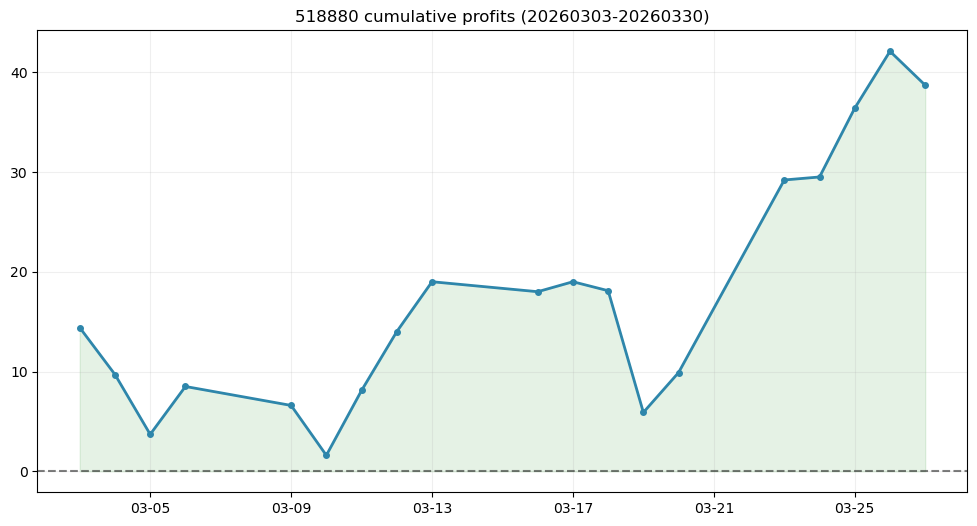

{'测试天数': 19, '累计总盈亏': np.float64(38.7), '总成交次数': 271, '日均盈亏': np.float64(2.04), '胜率(天)%': 57.89, '盈亏比(日均)': np.float64(1.53), '最大单日盈利': 19.3, '最大单日亏损': -12.2, '每笔交易平均盈利': np.float64(0.14)}


In [62]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from multi_day_backtest import backtest_multi_days, backtest_summary
from delta.strategy import StrategyDemo

result_df = backtest_multi_days(
    instrument_id=instrument_id,
    start_ymd='20260303',
    end_ymd='20260330',
    StrategyClass= StrategyDemo,
    model = model,
    param_dict=param_dict,
    official = False
)

summary = backtest_summary(result_df)
print(summary)

In [63]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(result_df)

,trade_ymd,profits,trades,trade_date
0,20260303,14.4,19,2026-03-03
1,20260304,-4.7,26,2026-03-04
2,20260305,-6.0,21,2026-03-05
3,20260306,4.8,8,2026-03-06
4,20260309,-1.9,18,2026-03-09
5,20260310,-5.0,11,2026-03-10
6,20260311,6.5,7,2026-03-11
7,20260312,5.9,9,2026-03-12
8,20260313,5.0,8,2026-03-13
9,20260316,-1.0,13,2026-03-16


## 保存回测结果

In [64]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果
result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260413_021649
回测结果已保存到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260413_021649
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [42]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260408", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("518880", "20260408", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹

总共删除了 0 个文件夹


## 单日回测观察

In [43]:
instrument_id = '518880'
trade_ymd = '20260319'


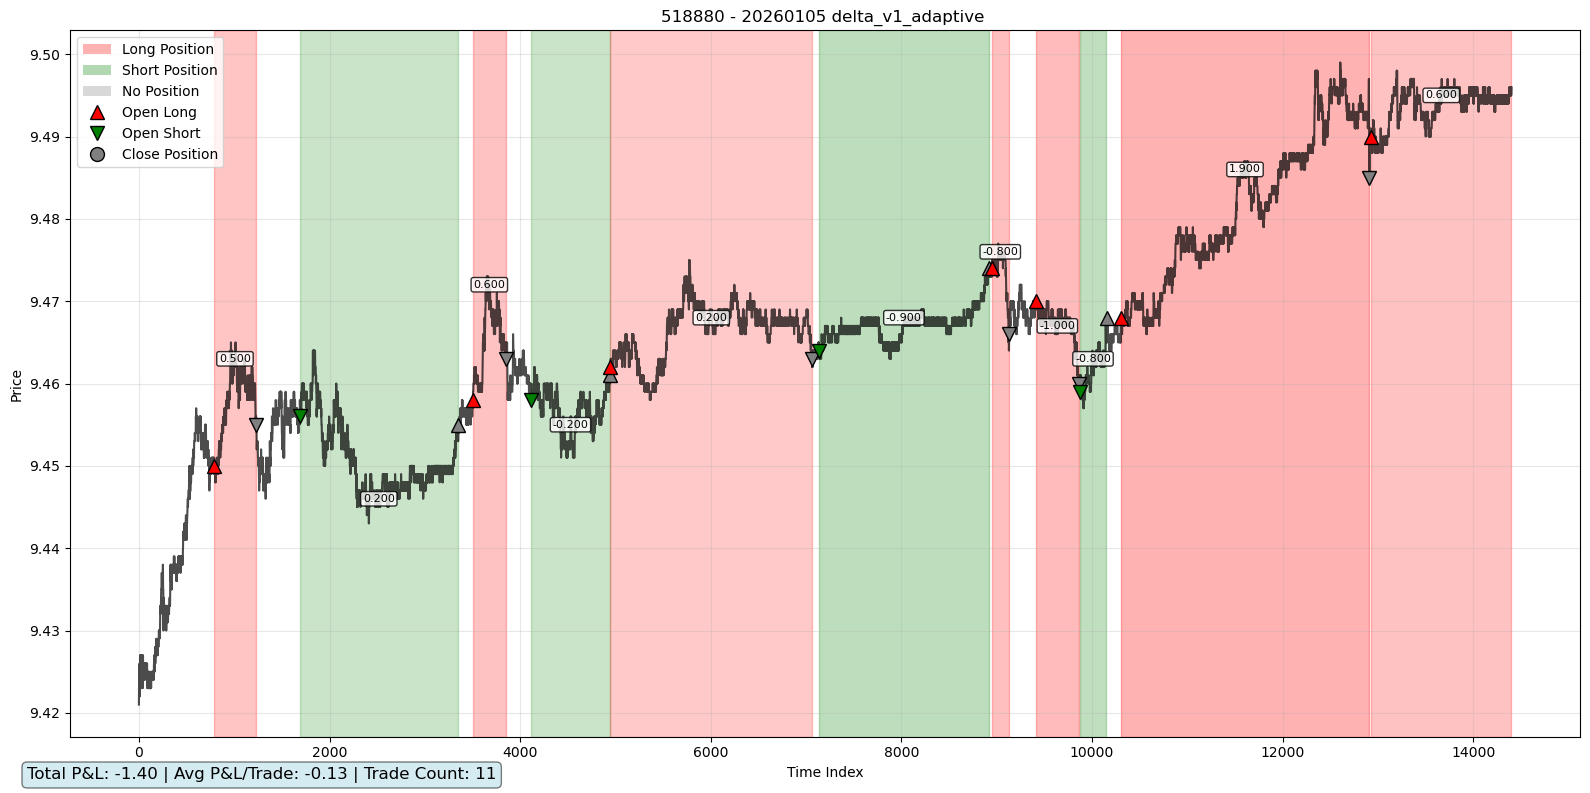

In [44]:
from single_day_backtest import single_day_backtest
hh = single_day_backtest(instrument_id,'20260105',StrategyDemo,model,param_dict,official = False)

## 自适应参数总结

### 优势

1. **数据驱动**: 参数基于验证集表现动态计算，而非固定值
2. **适应性**: 自动适应不同市场环境和数据分布
3. **优化性**: XGBoost样本权重根据验证集表现优化，提高模型精准性
4. **自动化**: 整个流程自动化，无需手动调参

### 实现的功能

1. **自适应阈值计算**: 
   - `open_confidence`: 验证集可信样本概率的中位数
   - `close_confidence`: 验证集可信样本概率的75分位数

2. **自适应样本权重**:
   - XGBoost `scale_pos_weight` 根据验证集表现优化
   - 在保证召回率的前提下提高精准性

3. **向后兼容**:
   - 策略类自动使用计算出的自适应参数
   - 原有代码无需修改即可使用新功能

### 使用说明

1. 训练模型后，自适应参数会自动计算并更新到参数字典
2. 策略实例创建时会自动使用这些参数
3. 回测和实际交易中，策略会根据自适应阈值进行决策

### 验证

自适应参数基于验证集计算，确保：
1. 阈值设置合理，避免过度交易
2. 模型权重优化，提高预测准确性
3. 策略表现稳定，适应市场变化